In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('Documents/D598 Data Set.xlsx')

In [12]:
df_dti = pd.DataFrame({
    'Debt to Income Ratio': np.where(
        df['Total Revenue'] == 0,
        np.nan,
        df['Total Long-term Debt'] / df['Total Revenue']
    )

})
df_final = pd.concat(
    [df.reset_index(drop=True),df_dti.reset_index(drop=True)],
    axis=1
)

In [5]:
#Bar Chart Average Revenue by State

#Group and sum total revenue by state
df_by_state = (df.groupby("Business State")["Total Revenue"]
               .sum()
               .reset_index()
              )

In [6]:
#Sort from highest to lowest and take top 5
df_top5 = df_by_state.sort_values("Total Revenue", ascending=False).head(5)

Text(0, 0.5, 'Total Revenue')

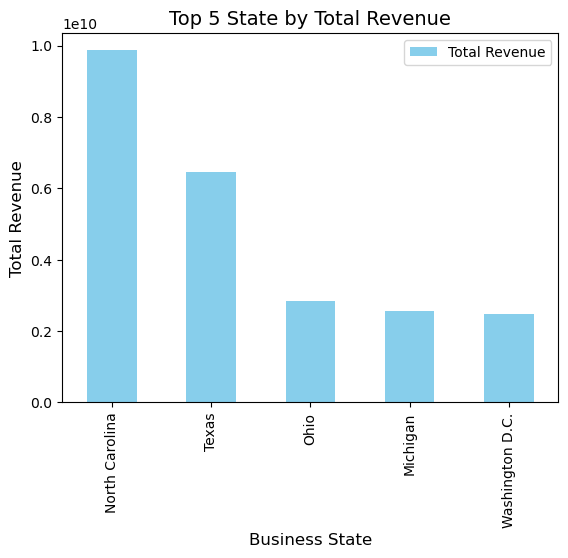

In [7]:
#Plot the bar chart
ax = df_top5.plot(
    x="Business State",
    y="Total Revenue",
    kind="bar",
    color="skyblue"
)

#Add chart titles and labels
plt.title("Top 5 State by Total Revenue", fontsize=14)
plt.xlabel("Business State", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

In [8]:
#Line Chart Business Total Revenue vs Total Debt

#Group data by state and sum total revenue and total debt
df_by_state = (
    df.groupby("Business State")[["Total Revenue", "Total Long-term Debt"]]
    .sum()
    .reset_index()
              )

In [9]:
#Sort by Total Debt (highest to lowest)
df_top5 = df_by_state.sort_values("Total Long-term Debt", ascending=False).head(5)

Text(0, 0.5, 'Total Revenue')

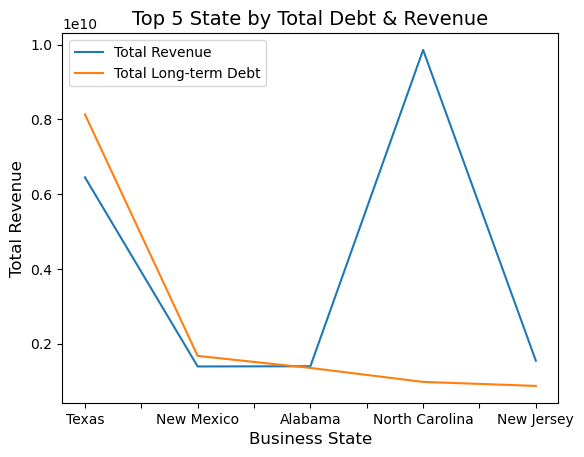

In [35]:
#Plot the line chart
ax = df_top5.plot(
    x="Business State",
    y=["Total Revenue", "Total Long-term Debt"],
    kind="line",
)

#Add chart titles and labels
plt.title("Top 5 State by Total Debt & Revenue", fontsize=14)
plt.xlabel("Business State", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

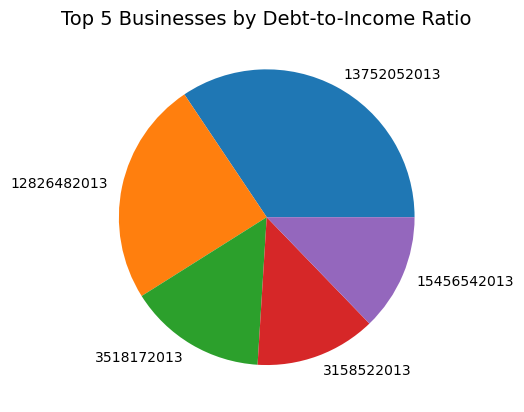

In [14]:
#Sort data by Debt-to-Income Ratio (highest to lowest)
df_top5_dti = df_final.sort_values("Debt to Income Ratio", ascending=False).head(5)

#Create pie chart
plt.pie(
    df_top5_dti["Debt to Income Ratio"],
    labels=df_top5_dti["Business ID"],
    )
plt.title("Top 5 Businesses by Debt-to-Income Ratio", fontsize=14)
plt.show()

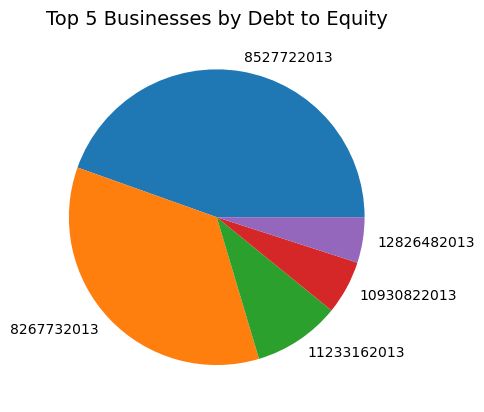

In [16]:
#Sort data by Debt-to-Equity Ratio (highest to lowest)
df_top5_dte = df.sort_values("Debt to Equity", ascending=False).head(5)

#Create pie chart
plt.pie(
    df_top5_dte["Debt to Equity"],
    labels=df_top5_dte["Business ID"],
    )
plt.title("Top 5 Businesses by Debt to Equity", fontsize=14)
plt.show()